Technique table preview (capped years):
dataset attack_label tactic technique_id         technique_name  year_first_seen  effective_year  frequency
NSL-KDD      neptune TA0040    T1498.001   Direct Network Flood           2020.0            1998      45870
NSL-KDD        satan TA0043    T1595.002 Vulnerability Scanning           2020.0            1998       4368
NSL-KDD      ipsweep TA0043    T1595.001     Scanning IP Blocks           2020.0            1998       3740
NSL-KDD        smurf TA0040    T1498.001   Direct Network Flood           2020.0            1998       3311
NSL-KDD    portsweep TA0043    T1595.001     Scanning IP Blocks           2020.0            1998       3088

Attack Sophistication (AS) per dataset:

        dataset     mu     pL     pM     pH       H   HSCT    D  r_modern     CF     AS
        ToN_IoT 0.2970 0.5498 0.4502 0.0000  0.6264 0.0000 0.00    0.7778 0.3657 0.3671
CSE-CIC-IDS2018 0.2784 0.8368 0.1632 0.0000  0.4050 0.0000 0.00    0.0000 0.2833 0.2290
      

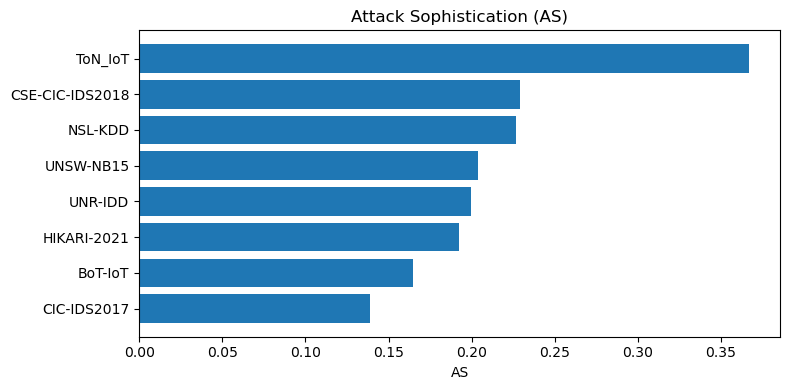

In [1]:
# Attack Sophistication (AS) — modernity fixed:
# - Use x_mitre_first_seen, else CREATED (never modified)
# - Cap technique year by dataset year to prevent inflation (effective_year = min(tech_year, dataset_year))

import os, re, json
import pandas as pd
import numpy as np
from typing import Dict, Iterable, List, Tuple

# =========================
# 0) Inputs (as code)
# =========================

attack_distribution = {
    "NSL-KDD": {
        "normal": 77053,
        "neptune": 45870, "satan": 4368, "ipsweep": 3740, "smurf": 3311, "portsweep": 3088,
        "nmap": 1566, "back": 1315, "guess_passwd": 1284, "mscan": 996, "warezmaster": 964,
        "teardrop": 904, "warezclient": 890, "apache2": 737, "processtable": 685, "snmpguess": 331,
        "saint": 319, "mailbomb": 293, "pod": 242, "snmpgetattack": 178, "httptunnel": 133,
        "buffer_overflow": 50, "land": 25, "multihop": 25, "rootkit": 23, "named": 17, "ps": 15,
        "sendmail": 14, "xterm": 13, "imap": 12, "loadmodule": 11, "ftp_write": 11, "xlock": 9,
        "phf": 6, "perl": 5, "xsnoop": 4, "spy": 2, "worm": 2, "sqlattack": 2, "udpstorm": 2
    },
    "UNSW-NB15": {
        "Normal": 93000, "Generic": 58871, "Exploits": 44525, "Fuzzers": 24246, "DoS": 16353,
        "Reconnaissance": 13987, "Analysis": 2677, "Backdoor": 2329, "Shellcode": 1511, "Worms": 174
    },
    "CIC-IDS2017": {
        "BENIGN": 2273097, "DoS Hulk": 231073, "PortScan": 158930, "DDoS": 128027,
        "DoS GoldenEye": 10293, "FTP-Patator": 7938, "SSH-Patator": 5897,
        "DoS slowloris": 5796, "DoS Slowhttptest": 5499,
        "Bot": 1966, "Web Attack   Brute Force": 1507, "Web Attack   XSS": 652,
        "Infiltration": 36, "Web Attack   Sql Injection": 21, "Heartbleed": 11
    },
    # counts key is "CSE-CSC-IDS2018"; we alias to mapping key "CSE-CIC-IDS2018"
    "CSE-CSC-IDS2018": {
        "Benign": 13484708, "DDOS attack-HOIC": 686012, "DDoS attacks-LOIC-HTTP": 576191,
        "DoS attacks-Hulk": 461912, "Bot": 286191, "FTP-BruteForce": 193360,
        "SSH-Bruteforce": 187589, "Infilteration": 161934, "DoS attacks-SlowHTTPTest": 139890,
        "DoS attacks-GoldenEye": 41508, "DoS attacks-Slowloris": 10990,
        "DDOS attack-LOIC-UDP": 1730, "Brute Force -Web": 611, "Brute Force -XSS": 230,
        "SQL Injection": 87, "Label": 59
    },
    "ToN_IoT": {
        "normal": 41877, "scanning": 20000, "ddos": 19986, "injection": 19952, "password": 19791,
        "dos": 17984, "backdoor": 17488, "ransomware": 13226, "xss": 11961, "mitm": 1039
    },
    "BoT-IoT": {
        "Normal": 477, "DDoS": 1926624, "DoS": 1650260, "Reconnaissance": 91082, "Theft": 79
    },
    "HIKARI-2021": {
        "Benign": 347431, "Background": 170151, "Probing": 23388,
        "Bruteforce": 5884, "Bruteforce-XML": 5145, "XMRIGCC CryptoMiner": 3279
    },
    "UNR-IDD": {
        "Normal": 3773, "PortScan": 9498, "TCP-SYN": 9081, "Blackhole": 8420,
        "Diversion": 5615, "Overflow": 1022
    }
}

technique_mapping = {
    "NSL-KDD": {
        "neptune": ("TA0040", "T1498.001"), "satan": ("TA0043", "T1595.002"),
        "ipsweep": ("TA0043", "T1595.001"), "smurf": ("TA0040", "T1498.001"),
        "portsweep": ("TA0043", "T1595.001"), "nmap": ("TA0043", "T1595.001"),
        "back": ("TA0040", "T1499.002"), "guess_passwd": ("TA0006", "T1110.001"),
        "mscan": ("TA0043", "T1595.002"), "warezmaster": ("TA0011", "T1105"),
        "teardrop": ("TA0040", "T1498.001"), "warezclient": ("TA0011", "T1105"),
        "apache2": ("TA0040", "T1498.003"), "processtable": ("TA0040", "T1499.001"),
        "snmpguess": ("TA0006", "T1110.001"), "saint": ("TA0043", "T1595.001"),
        "mailbomb": ("TA0040", "T1499.002"), "pod": ("TA0040", "T1498.001"),
        "snmpgetattack": ("TA0007", "T1046"), "httptunnel": ("TA0011", "T1572"),
        "buffer_overflow": ("TA0004", "T1068"), "land": ("TA0040", "T1498.001"),
        "multihop": ("TA0011", "T1090"), "rootkit": ("TA0005", "T1014"),
        "named": ("TA0001", "T1190"), "ps": ("TA0007", "T1057"),
        "sendmail": ("TA0004", "T1068"), "xterm": ("TA0002", "T1059"),
        "imap": ("TA0006", "T1110.001"), "loadmodule": ("TA0002", "T1059"),
        "ftp_write": ("TA0011", "T1105"), "xlock": ("TA0006", "T1110.001"),
        "phf": ("TA0001", "T1190"), "perl": ("TA0002", "T1059"),
        "xsnoop": ("TA0006", "T1040"), "spy": ("TA0009", "T1113"),
        "worm": ("TA0008", "T1210"), "sqlattack": ("TA0001", "T1190"),
        "udpstorm": ("TA0040", "T1498.002"),
    },
    "UNSW-NB15": {
        "generic": ("TA0040", "T1498.001"), "exploits": ("TA0001", "T1190"),
        "fuzzers": ("TA0043", "T1595.002"), "dos": ("TA0040", "T1498.001"),
        "reconnaissance": ("TA0043", "T1595.001"), "analysis": ("TA0043", "T1595.002"),
        "backdoor": ("TA0003", "T1547"), "shellcode": ("TA0002", "T1203"),
        "worms": ("TA0008", "T1210"),
    },
    "CIC-IDS2017": {
        "DoS Hulk": ("TA0040", "T1499.003"),
        "PortScan": ("TA0043", "T1595.001"),
        "DDoS": ("TA0040", "T1498.001"),
        "DoS GoldenEye": ("TA0040", "T1499.003"),
        "FTP-Patator": ("TA0006", "T1110.001"),
        "SSH-Patator": ("TA0006", "T1110.001"),
        "DoS slowloris": ("TA0040", "T1499.002"),
        "DoS Slowhttptest": ("TA0040", "T1499.001"),
        "Bot": ("TA0011", "T1071.001"),
        "Web Attack   Brute Force": ("TA0006", "T1110.001"),
        "Web Attack   XSS": ("TA0001", "T1190"),
        "Infiltration": ("TA0001", "T1190"),
        "Web Attack   Sql Injection": ("TA0001", "T1190"),
        "Heartbleed": ("TA0001", "T1190"),
    },
    "CSE-CIC-IDS2018": {
        "DDOS attack-HOIC": ("TA0040", "T1499.003"),
        "DDoS attacks-LOIC-HTTP": ("TA0040", "T1499.003"),
        "DDoS attack-LOIC-UDP": ("TA0040", "T1498.001"),
        "DoS attacks-Hulk": ("TA0040", "T1499.003"),
        "DoS attacks-GoldenEye": ("TA0040", "T1499.003"),
        "DoS attacks-SlowHTTPTest": ("TA0040", "T1499.002"),
        "DoS attacks-Slowloris": ("TA0040", "T1499.002"),
        "Bot": ("TA0011", "T1071.001"),
        "FTP-BruteForce": ("TA0006", "T1110.001"),
        "SSH-Bruteforce": ("TA0006", "T1110.001"),
        "Infilteration": ("TA0001", "T1190"),
        "Infiltration": ("TA0001", "T1190"),
        "Brute Force -Web": ("TA0006", "T1110.001"),
        "Brute Force -XSS": ("TA0001", "T1190"),
        "SQL Injection": ("TA0001", "T1190"),
    },
    "BoT-IoT": {
        "DDoS": ("TA0040", "T1498.001"), "DoS": ("TA0040", "T1498.001"),
        "Reconnaissance": ("TA0043", "T1595.001"), "Theft": ("TA0010", "T1041"),
    },
    "ToN_IoT": {
        "Scanning": ("TA0043", "T1595.001"), "DDoS": ("TA0040", "T1498.001"),
        "Injection": ("TA0001", "T1190"), "Password": ("TA0006", "T1110.001"),
        "DoS": ("TA0040", "T1499"), "Backdoor": ("TA0003", "T1547"),
        "Ransomware": ("TA0040", "T1486"), "XSS": ("TA0001", "T1190"),
        "MITM": ("TA0006", "T1557"),
    },
    "HIKARI-2021": {
        "Probing": ("TA0043", "T1595"),
        "Bruteforce": ("TA0006", "T1110.001"),
        "Bruteforce-XML": ("TA0006", "T1110"),
        "XMRIGCC CryptoMiner": ("TA0040", "T1496"),
    },
    "UNR-IDD": {
        "PortScan": ("TA0043", "T1595.001"),
        "TCP-SYN": ("TA0040", "T1498.001"),
        "Blackhole": ("TA0040", "T1498.001"),
        "Diversion": ("TA0040", "T1498.001"),
        "Overflow": ("TA0040", "T1499"),
    }
}

dataset_year = {
    "NSL-KDD": 1998,
    "UNSW-NB15": 2015,
    "CIC-IDS2017": 2017,
    "CSE-CIC-IDS2018": 2018,
    "ToN_IoT": 2021,
    "BoT-IoT": 2018,
    "UNR-IDD": 2020,
    "HIKARI-2021": 2021
}

technique_rubric: Dict[str, Dict[str, int]] = {
    "T1595": {"EC":0,"RR":0,"SE":0,"CD":0},
    "T1595.001": {"EC":0,"RR":0,"SE":0,"CD":0},
    "T1595.002": {"EC":1,"RR":0,"SE":0,"CD":0},

    "T1498.001": {"EC":1,"RR":2,"SE":0,"CD":0},
    "T1498.002": {"EC":2,"RR":2,"SE":0,"CD":1},
    "T1498.003": {"EC":2,"RR":2,"SE":0,"CD":1},
    "T1499": {"EC":1,"RR":1,"SE":0,"CD":0},
    "T1499.001": {"EC":1,"RR":1,"SE":0,"CD":0},
    "T1499.002": {"EC":1,"RR":1,"SE":0,"CD":0},
    "T1499.003": {"EC":2,"RR":1,"SE":0,"CD":0},

    "T1110": {"EC":1,"RR":1,"SE":0,"CD":0},
    "T1110.001": {"EC":1,"RR":1,"SE":0,"CD":0},

    "T1190": {"EC":2,"RR":1,"SE":1,"CD":1},
    "T1203": {"EC":2,"RR":1,"SE":1,"CD":1},
    "T1210": {"EC":3,"RR":2,"SE":2,"CD":2},

    "T1105": {"EC":1,"RR":1,"SE":1,"CD":1},
    "T1572": {"EC":2,"RR":1,"SE":2,"CD":2},
    "T1090": {"EC":1,"RR":1,"SE":2,"CD":1},
    "T1071.001": {"EC":2,"RR":1,"SE":2,"CD":2},

    "T1046": {"EC":0,"RR":0,"SE":0,"CD":0},
    "T1057": {"EC":0,"RR":0,"SE":0,"CD":0},
    "T1059": {"EC":1,"RR":0,"SE":1,"CD":1},

    "T1014": {"EC":3,"RR":2,"SE":3,"CD":2},
    "T1547": {"EC":2,"RR":1,"SE":2,"CD":2},
    "T1068": {"EC":3,"RR":2,"SE":2,"CD":2},

    "T1041": {"EC":2,"RR":1,"SE":2,"CD":2},
    "T1113": {"EC":1,"RR":0,"SE":1,"CD":1},
    "T1040": {"EC":1,"RR":1,"SE":1,"CD":1},
    "T1486": {"EC":2,"RR":1,"SE":1,"CD":2},
    "T1496": {"EC":2,"RR":2,"SE":2,"CD":2},

    "T1557": {"EC":2,"RR":1,"SE":2,"CD":2},
}

scope_profiles: Dict[str, Dict[str, float]] = {
    "NSL-KDD": {
        "TA0001":0.15,"TA0002":0.10,"TA0004":0.15,"TA0005":0.10,"TA0006":0.15,
        "TA0007":0.10,"TA0011":0.10,"TA0040":0.10,"TA0043":0.05
    },
    "UNSW-NB15": {
        "TA0001":0.20,"TA0002":0.10,"TA0003":0.10,"TA0006":0.10,
        "TA0008":0.10,"TA0040":0.20,"TA0043":0.20
    },
    "CIC-IDS2017": {"TA0040":0.35,"TA0006":0.20,"TA0001":0.20,"TA0011":0.15,"TA0043":0.10},
    "CSE-CIC-IDS2018": {"TA0040":0.40,"TA0006":0.20,"TA0011":0.15,"TA0001":0.15,"TA0043":0.10},
    "ToN_IoT": {"TA0040":0.30,"TA0001":0.20,"TA0003":0.10,"TA0006":0.20,"TA0043":0.10,"TA0010":0.0},
    "BoT-IoT": {"TA0040":0.45,"TA0043":0.20,"TA0010":0.35},
    "HIKARI-2021": {"TA0043":0.35,"TA0006":0.35,"TA0040":0.30},
    "UNR-IDD": {"TA0040":0.60,"TA0043":0.40}
}

STIX_FILES = ["enterprise-attack.json", "ics-attack.json"]
CAP_YEAR_BY_DATASET = True   # <<< key change: cap technique year by dataset year
MODERN_YEAR = 2019

# =========================
# 1) STIX parsing (technique_id -> name, year_first_seen)
# =========================
def _extract_year(val) -> int or None:
    try:
        s = str(val)
        m = re.match(r"(\d{4})", s)
        return int(m.group(1)) if m else None
    except Exception:
        return None

def load_attack_tech_metadata(stix_files: List[str]) -> pd.DataFrame:
    """
    Return: technique_id, technique_name, year_first_seen
    Prefers x_mitre_first_seen; else CREATED year only (never 'modified').
    """
    rows: List[Dict[str, object]] = []
    pattern_tid = re.compile(r"^T\d{4}(?:\.\d{3})?$")

    for fn in stix_files:
        if not os.path.exists(fn):
            print(f"[WARN] STIX file not found: {fn}")
            continue
        try:
            with open(fn, "r", encoding="utf-8") as f:
                bundle = json.load(f)
        except Exception as e:
            print(f"[WARN] Failed to read {fn}: {e}")
            continue

        for obj in bundle.get("objects", []):
            if obj.get("type") != "attack-pattern":
                continue

            tid = None
            for ref in obj.get("external_references", []):
                ext_id = ref.get("external_id", "")
                if pattern_tid.match(ext_id or ""):
                    tid = ext_id
                    break
            if not tid:
                continue

            name = obj.get("name", tid)
            first_seen = obj.get("x_mitre_first_seen")
            year = _extract_year(first_seen)
            if not year:
                year = _extract_year(obj.get("created"))

            rows.append({"technique_id": tid, "technique_name": name, "year_first_seen": year})

    df = pd.DataFrame(rows).drop_duplicates(subset=["technique_id"])
    return df

tech_meta = load_attack_tech_metadata(STIX_FILES)
if tech_meta.empty:
    print("[WARN] No technique metadata extracted from STIX. Names/years will fall back where needed.")

# =========================
# 2) Helpers
# =========================
def normalize_label(s: str) -> str:
    return ''.join(ch for ch in s.lower() if ch.isalnum())

def to_numeric_int(x, default=0):
    try:
        return int(x)
    except Exception:
        return default

def rubric_lookup(tech_id: str, rubric: Dict[str, Dict[str, int]]) -> Dict[str,int]:
    if tech_id in rubric:
        return rubric[tech_id]
    if '.' in tech_id:
        base = tech_id.split('.')[0]
        if base in rubric:
            return rubric[base]
    return {"EC":0,"RR":0,"SE":0,"CD":0}

# =========================
# 3) Build techniques_df with STIX names + (capped) years
# =========================
def build_techniques_df(attack_distribution: Dict[str, Dict[str,int]],
                        technique_mapping: Dict[str, Dict[str, Tuple[str,str]]],
                        dataset_year: Dict[str,int],
                        tech_meta: pd.DataFrame,
                        cap_year_by_dataset: bool = True) -> pd.DataFrame:
    rows = []
    for dataset, label_counts in attack_distribution.items():
        ds = "CSE-CIC-IDS2018" if dataset == "CSE-CSC-IDS2018" else dataset
        mapping = technique_mapping.get(ds, {})
        if not mapping:
            print(f"[WARN] No technique mapping for dataset '{ds}'. Skipping its labels.")
            continue

        norm_map = { normalize_label(k): (tac, tid) for k,(tac,tid) in mapping.items() }

        for raw_label, count in label_counts.items():
            norm_label = normalize_label(raw_label)
            if norm_label in ["normal","benign","background","label"]:
                continue
            if norm_label not in norm_map:
                print(f"[WARN] Label '{raw_label}' in '{ds}' has no mapping. Skipping.")
                continue
            tactic, technique_id = norm_map[norm_label]
            rows.append({
                "dataset": ds,
                "attack_label": raw_label,
                "tactic": tactic,
                "technique_id": technique_id,
                "frequency": to_numeric_int(count, default=1),
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("[WARN] No attack techniques rows were built.")
        return df

    # Merge technique metadata (name + per-technique year)
    if tech_meta is not None and not tech_meta.empty:
        df = df.merge(tech_meta, on="technique_id", how="left")
    else:
        df["technique_name"] = None
        df["year_first_seen"] = None

    # Fallbacks
    df["technique_name"] = df["technique_name"].fillna(df["technique_id"])
    df["year_first_seen"] = pd.to_numeric(df["year_first_seen"], errors="coerce")

    # Add dataset year and compute EFFECTIVE year (cap)
    df["dataset_year"] = df["dataset"].map(dataset_year)
    # If missing technique year, fallback to dataset year
    df.loc[df["year_first_seen"].isna(), "year_first_seen"] = df.loc[df["year_first_seen"].isna(), "dataset_year"]

    if cap_year_by_dataset:
        df["effective_year"] = np.minimum(df["year_first_seen"].astype(int), df["dataset_year"].astype(int))
    else:
        df["effective_year"] = df["year_first_seen"].astype(int)

    # Clean up
    df.drop(columns=["dataset_year"], inplace=True)

    return df

techniques_df = build_techniques_df(
    attack_distribution, technique_mapping, dataset_year, tech_meta,
    cap_year_by_dataset=CAP_YEAR_BY_DATASET
)

# =========================
# 4) AS computation
# =========================
def _safe_clip_int(df, cols: Iterable[str], lo=0, hi=3):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).clip(lo, hi).astype(int)
    return df

def _weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    W = weights.sum()
    return 0.0 if W == 0 else float((values*weights).sum()/W)

def _entropy(proportions):
    p = np.asarray(proportions, dtype=float)
    p = p[p > 0]
    return 0.0 if p.size == 0 else float(-(p*np.log(p)).sum()/np.log(3))

def _tier_bins(scores, weights=None):
    s = np.asarray(scores, dtype=float)
    w = np.ones_like(s) if weights is None else np.asarray(weights, dtype=float)
    if w.sum() == 0:
        return 0.0,0.0,0.0
    L = s < 0.33
    M = (s >= 0.33) & (s <= 0.66)
    H = s > 0.66
    W = w.sum()
    return float(w[L].sum()/W), float(w[M].sum()/W), float(w[H].sum()/W)

def _hsct(df_dataset, score_col='s', high_threshold=0.66):
    if df_dataset.empty:
        return 0.0
    tactics_present = df_dataset['tactic'].unique()
    if tactics_present.size == 0:
        return 0.0
    has_high = (
        df_dataset.assign(high=lambda d: d[score_col] > high_threshold)
                  .groupby('tactic', as_index=False)['high'].max()
    )
    return float(has_high['high'].sum() / len(tactics_present))

def _dominance_penalty(df_dataset, score_col='s', high_threshold=0.66, tau=0.25, weight_col='frequency'):
    dd = df_dataset[df_dataset[score_col] > high_threshold]
    if dd.empty:
        return 0.0
    w = dd[weight_col].to_numpy(float)
    contrib = w * dd[score_col].to_numpy(float)
    S = contrib.sum()
    if S <= 0:
        return 0.0
    c = contrib / S
    hhi = float((c**2).sum())
    return float(max(0.0, hhi - tau))

def _context_fit(df_dataset, tactic_weights: Dict[str,float], score_col='s', topk=2):
    if df_dataset.empty or not tactic_weights:
        return 0.0
    total = sum(tactic_weights.values())
    if total <= 0:
        observed = df_dataset['tactic'].unique().tolist()
        tactic_weights = {t: 1.0/len(observed) for t in observed}
    else:
        tactic_weights = {t: w/total for t, w in tactic_weights.items()}

    val = 0.0
    for t, wt in tactic_weights.items():
        tt = df_dataset[df_dataset['tactic'] == t]
        if tt.empty:
            continue
        top_scores = np.sort(tt[score_col].to_numpy(float))[-topk:]
        d_t = float(np.mean(top_scores)) if top_scores.size > 0 else 0.0
        val += wt * d_t
    return float(val)

def _modern_share(df_dataset, modern_year=MODERN_YEAR):
    if df_dataset.empty or 'effective_year' not in df_dataset.columns:
        return 0.0
    years = pd.to_numeric(df_dataset['effective_year'], errors='coerce').fillna(0).to_numpy()
    return float((years >= modern_year).mean())

def compute_as(
    techniques_df: pd.DataFrame,
    technique_rubric: Dict[str, Dict[str,int]],
    scope_profiles: Dict[str, Dict[str,float]] = None,
    w_dims: Dict[str,float] = None,
    alpha=0.35, beta=0.15, gamma=0.15, delta=0.25, epsilon=0.10, zeta=0.10,
    high_threshold=0.66, dominance_tau=0.25, topk=2, weight_col='frequency'
) -> pd.DataFrame:
    """
    AS = α·μ + β·H + γ·HSCT + δ·CF + ε·r_modern − ζ·D
    Modernity uses 'effective_year' (tech year capped by dataset year).
    """
    if techniques_df.empty:
        raise ValueError("No techniques to score. Check your inputs.")

    df = techniques_df.copy()
    if weight_col not in df.columns:
        df[weight_col] = 1.0
    df[weight_col] = pd.to_numeric(df[weight_col], errors='coerce').fillna(1.0).clip(lower=0.0)

    # Attach EC/RR/SE/CD via rubric
    ECs, RRs, SEs, CDs = [], [], [], []
    for tech in df['technique_id']:
        r = rubric_lookup(tech, technique_rubric)
        ECs.append(r["EC"]); RRs.append(r["RR"]); SEs.append(r["SE"]); CDs.append(r["CD"])
    df['EC'], df['RR'], df['SE'], df['CD'] = ECs, RRs, SEs, CDs
    df = _safe_clip_int(df, ['EC','RR','SE','CD'], 0, 3)

    # Per-technique sophistication s(a) in [0,1]
    if w_dims is None:
        w_dims = {'EC':1.0, 'RR':1.0, 'SE':1.0, 'CD':1.0}
    denom = 3.0 * (w_dims['EC'] + w_dims['RR'] + w_dims['SE'] + w_dims['CD'])
    if denom <= 0:
        raise ValueError("Sum of dimension weights must be > 0.")
    df['s'] = (
        w_dims['EC']*df['EC'] + w_dims['RR']*df['RR'] +
        w_dims['SE']*df['SE'] + w_dims['CD']*df['CD']
    ) / denom
    df['s'] = df['s'].clip(0,1)

    # Components per dataset
    out = []
    for dataset, g in df.groupby('dataset', sort=False):
        mu = _weighted_mean(g['s'].to_numpy(), g[weight_col].to_numpy())
        pL, pM, pH = _tier_bins(g['s'].to_numpy(), g[weight_col].to_numpy())
        H = _entropy([pL,pM,pH])
        HSCT = _hsct(g, score_col='s', high_threshold=high_threshold)
        D = _dominance_penalty(g, score_col='s', high_threshold=high_threshold, tau=dominance_tau, weight_col=weight_col)
        r_modern = _modern_share(g)  # uses effective_year

        et = scope_profiles.get(dataset, None) if scope_profiles is not None else None
        if et is None:
            tactics = g['tactic'].dropna().unique().tolist()
            et = {t: 1.0/len(tactics) for t in tactics} if tactics else {}
        CF = _context_fit(g, et, score_col='s', topk=topk)

        AS = float(np.clip(alpha*mu + beta*H + gamma*HSCT + delta*CF + 0.10*r_modern - zeta*D, 0.0, 1.0))

        out.append({
            "dataset": dataset,
            "mu": round(mu,4), "pL": round(pL,4), "pM": round(pM,4), "pH": round(pH,4),
            "H": round(H,4), "HSCT": round(HSCT,4), "D": round(D,4),
            "r_modern": round(r_modern,4), "CF": round(CF,4), "AS": round(AS,4)
        })
    return pd.DataFrame(out)

# =========================
# 5) Run & Inspect
# =========================
if techniques_df.empty:
    raise SystemExit("No techniques built. Please check mappings and distributions.")

print("Technique table preview (capped years):")
print(techniques_df[['dataset','attack_label','tactic','technique_id','technique_name','year_first_seen','effective_year','frequency']].head().to_string(index=False))

results = compute_as(
    techniques_df,
    technique_rubric=technique_rubric,
    scope_profiles=scope_profiles,
    w_dims={'EC':1,'RR':1,'SE':1,'CD':1},
    alpha=0.35, beta=0.15, gamma=0.15, delta=0.25, zeta=0.10,  # epsilon fixed at 0.10 inside compute_as
    high_threshold=0.66, dominance_tau=0.25, topk=2, weight_col='frequency'
)

print("\nAttack Sophistication (AS) per dataset:\n")
print(results.sort_values("AS", ascending=False).to_string(index=False))

# Optional plot
try:
    import matplotlib.pyplot as plt
    _res = results.sort_values("AS", ascending=True)
    plt.figure(figsize=(8,4))
    plt.barh(_res['dataset'], _res['AS'])
    plt.title("Attack Sophistication (AS)")
    plt.xlabel("AS")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[INFO] Plotting skipped:", e)


In [3]:
results_sorted = results.sort_values("AS", ascending=False)
results_sorted.to_csv("AS_results.csv", index=False)

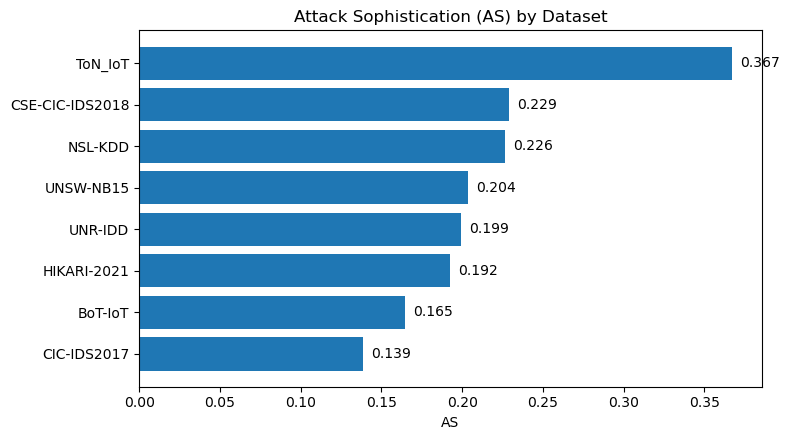

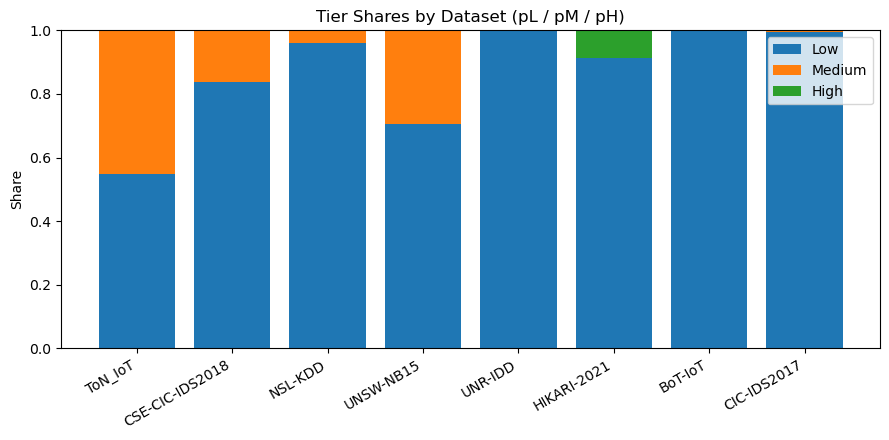

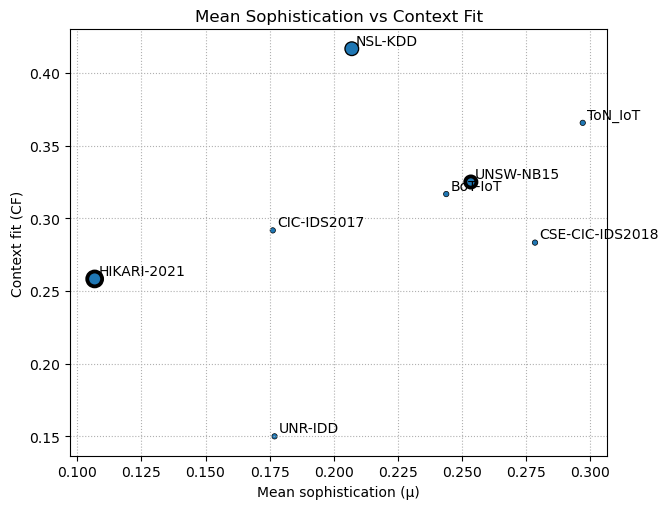

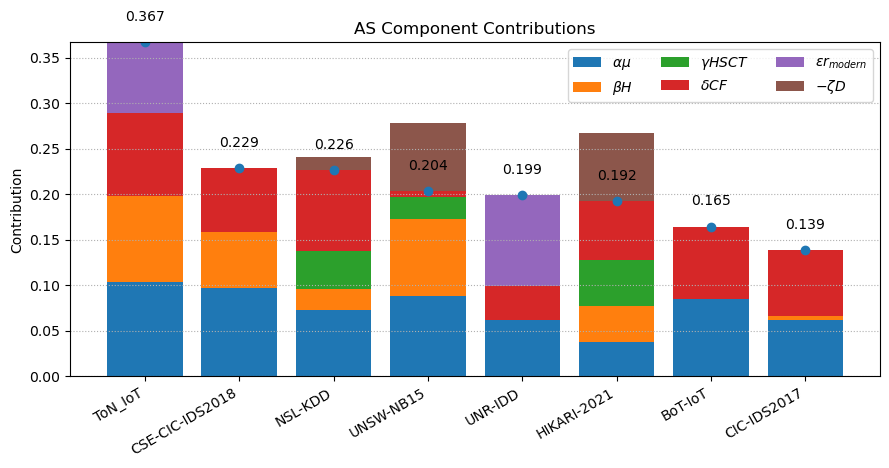

In [5]:
# ========= Visualization for Attack Sophistication (AS) =========
# Requirements: 'results' DataFrame from the AS computation
# Columns expected: dataset, mu, pL, pM, pH, H, HSCT, D, r_modern, CF, AS

import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- sanity checks ---------
required_cols = {"dataset","mu","pL","pM","pH","H","HSCT","D","r_modern","CF","AS"}
if 'results' not in globals():
    raise RuntimeError("The 'results' DataFrame was not found. Please run the AS computation cell first.")
missing = required_cols - set(results.columns)
if missing:
    raise RuntimeError(f"'results' is missing columns: {sorted(missing)}")

# --------- utility helpers ---------
def _ensure_dir(dirname="AS_figures"):
    if not os.path.exists(dirname):
        os.makedirs(dirname)
    return dirname

def _fname(title, ext):
    safe = "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in title)
    return safe + ext

def _savefig(fig, title, outdir="AS_figures"):
    outdir = _ensure_dir(outdir)
    fig.savefig(os.path.join(outdir, _fname(title, ".png")), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(outdir, _fname(title, ".pdf")), bbox_inches="tight")

# --------- 1) Horizontal bar: AS by dataset ---------
def plot_as_bar(results_df, outdir="AS_figures", title="Attack Sophistication (AS) by Dataset"):
    df = results_df.copy().sort_values("AS", ascending=True)
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.barh(df["dataset"], df["AS"])
    ax.set_xlabel("AS")
    ax.set_title(title)
    # annotate bars with values
    for y, v in enumerate(df["AS"]):
        ax.text(v + 0.005, y, f"{v:.3f}", va="center")
    plt.tight_layout()
    _savefig(fig, title, outdir)
    plt.show()

# --------- 2) Stacked bar: tier shares (pL, pM, pH) ---------
def plot_tier_stacked(results_df, outdir="AS_figures", title="Tier Shares by Dataset (pL / pM / pH)"):
    df = results_df.copy().sort_values("AS", ascending=False)
    x = np.arange(len(df))
    pL, pM, pH = df["pL"].to_numpy(), df["pM"].to_numpy(), df["pH"].to_numpy()

    fig = plt.figure(figsize=(9, 4.5))
    ax = fig.add_subplot(111)
    b1 = ax.bar(x, pL, label="Low")
    b2 = ax.bar(x, pM, bottom=pL, label="Medium")
    b3 = ax.bar(x, pH, bottom=pL+pM, label="High")
    ax.set_xticks(x)
    ax.set_xticklabels(df["dataset"], rotation=30, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Share")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    _savefig(fig, title, outdir)
    plt.show()

# --------- 3) Scatter: μ vs CF (size=HSCT, edge shows dominance) ---------
def plot_scatter_mu_cf(results_df, outdir="AS_figures", title="Mean Sophistication vs Context Fit"):
    df = results_df.copy()
    # marker size encodes HSCT; add a floor for visibility
    sizes = 300 * (df["HSCT"].to_numpy() + 0.05)
    # edge width encodes dominance severity (0..1 mapped to 0.5..3.5)
    lw = 0.5 + 3.0 * np.clip(df["D"].to_numpy(), 0, 1)

    fig = plt.figure(figsize=(6.8, 5.2))
    ax = fig.add_subplot(111)
    sc = ax.scatter(df["mu"], df["CF"], s=sizes, linewidths=lw, edgecolors="black")
    ax.set_xlabel("Mean sophistication (μ)")
    ax.set_ylabel("Context fit (CF)")
    ax.set_title(title)
    # annotate
    for _, r in df.iterrows():
        ax.annotate(r["dataset"], (r["mu"], r["CF"]), xytext=(3, 3), textcoords="offset points")
    # simple grid
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    _savefig(fig, title, outdir)
    plt.show()

# --------- 4) Stacked contributions: αμ, βH, γHSCT, δCF, εr_modern, −ζD ---------
def plot_as_contributions(results_df,
                          alpha=0.35, beta=0.15, gamma=0.15, delta=0.25, epsilon=0.10, zeta=0.10,
                          outdir="figures", title="AS Component Contributions"):
    df = results_df.copy().sort_values("AS", ascending=False)

    c_mu = alpha * df["mu"].to_numpy()
    c_H  = beta  * df["H"].to_numpy()
    c_HS = gamma * df["HSCT"].to_numpy()
    c_CF = delta * df["CF"].to_numpy()
    c_rm = epsilon * df["r_modern"].to_numpy()
    c_D  = -zeta * df["D"].to_numpy()     # subtractive

    # we will stack positive parts and then add the negative dominance as a separate bar on top
    x = np.arange(len(df))
    fig = plt.figure(figsize=(9, 4.8))
    ax = fig.add_subplot(111)

    b1 = ax.bar(x, c_mu, label=r"$\alpha\mu$")
    b2 = ax.bar(x, c_H, bottom=c_mu, label=r"$\beta H$")
    b3 = ax.bar(x, c_HS, bottom=c_mu + c_H, label=r"$\gamma HSCT$")
    b4 = ax.bar(x, c_CF, bottom=c_mu + c_H + c_HS, label=r"$\delta CF$")
    b5 = ax.bar(x, c_rm, bottom=c_mu + c_H + c_HS + c_CF, label=r"$\varepsilon r_{modern}$")

    # Dominance is negative; plot it as bars starting from the top of the stack
    pos_stack = c_mu + c_H + c_HS + c_CF + c_rm
    b6 = ax.bar(x, c_D, bottom=pos_stack, label=r"$-\zeta D$")

    ax.set_xticks(x)
    ax.set_xticklabels(df["dataset"], rotation=30, ha="right")
    ax.set_ylabel("Contribution")
    ax.set_title(title)
    ax.legend(ncol=3)
    # reference dots for actual AS
    ax.plot(x, df["AS"].to_numpy(), marker="o", linestyle="None")
    for xi, val in zip(x, df["AS"].to_numpy()):
        ax.text(xi, val + 0.01*np.sign(val)+0.01, f"{val:.3f}", ha="center", va="bottom", rotation=0)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
    plt.tight_layout()
    _savefig(fig, title, outdir)
    plt.show()

# --------- Run all visualizations ---------
plot_as_bar(results, outdir="AS_figures", title="Attack Sophistication (AS) by Dataset")
plot_tier_stacked(results, outdir="AS_figures", title="Tier Shares by Dataset (pL / pM / pH)")
plot_scatter_mu_cf(results, outdir="AS_figures", title="Mean Sophistication vs Context Fit")
plot_as_contributions(results, outdir="AS_figures", title="AS Component Contributions")
